In [154]:
from ultralytics import YOLO
from pandas import DataFrame
import matplotlib.pyplot as plt
model = YOLO('yolov8m-seg.pt')

class ImageInfo:
    def __init__(self, path):
        self.path = path
        self.results = model(path)
        self.boxes = self.results[0].boxes
        self.xyxy = self.boxes.xyxy.cpu().numpy()
        self.classes = self.boxes.cls.cpu().numpy()
        self.all_names = self.results[0].names
        self.confidence = self.boxes.conf.cpu().numpy()
        self.names = [self.all_names[val] for val in self.classes]
        self.xywhn = self.boxes.xywhn.cpu().numpy()
        self.xyxyn = self.boxes.xyxyn.cpu().numpy()

    def boxes_class(self, name: str):
        res = [ind for ind, val in enumerate(self.classes) if self.all_names[val] in name]
        return res

    def box_info(self, index):
        xyxy = (round(float(item), 5) for item in self.xyxy[index])
        confidence = round(float(self.confidence[index]), 5)
        name = self.all_names[self.classes[index]]
        return (*xyxy, confidence, name)

    def data_frame(self):
        df = DataFrame(self.xyxy, columns=['xmin', 'ymin', 'xmax', 'ymax'])
        df['name'] = self.names
        df['confidence'] = self.confidence
        return df

    def suitcase_handbag_person(self, threshold):
        list_suitcase_handbag = self.boxes_class('suitcasehandbag')
        centers_s_h = {index: self.xywhn[index][:2] for index in list_suitcase_handbag}
        d = {}

        for s_h in list_suitcase_handbag:
            best_person = None
            best_distance = threshold + 1

            for person in self.boxes_class('person'):
                x_min, y_min, x_max, y_max = self.xyxyn[person]
                if x_min <= centers_s_h[s_h][0] <= x_max and y_min <= centers_s_h[s_h][1] <= y_max:
                    distance_c = self._distance_centers(person, s_h)
                    if distance_c < best_distance:
                        best_distance = distance_c
                        best_person = person

            if best_distance <= threshold:
                d[s_h] = (best_person, round(float(best_distance), 5))
            else:
                d[s_h] = None

        return d

    def _distance_centers(self, el_1, el_2):
        x_1, y_1 = self.xywhn[el_1][:2]
        x_2, y_2 = self.xywhn[el_2][:2]
        return ((x_1 - x_2) ** 2 + (y_1 - y_2) ** 2) ** 0.5

    def show_image(self):
        img_annotated = self.results[0].plot()
        plt.figure(figsize=(10,10))
        plt.imshow(img_annotated)
        plt.title('Segmentation objects')
        plt.axis('off')
        plt.show()


In [155]:
image = ImageInfo('street.jpg')
image.classes


image 1/1 D:\Python Project\TelRan\PythonProject\python-ai-62test\hw\_05_yolo\street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 handbag, 1 suitcase, 624.8ms
Speed: 4.7ms preprocess, 624.8ms inference, 16.3ms postprocess per image at shape (1, 3, 640, 512)


array([          2,           1,           0,           0,           0,           0,           0,          28,           2,          26], dtype=float32)

In [156]:
ind_persons = image.boxes_class('person')
ind_persons

[2, 3, 4, 5, 6]

In [157]:
f = image.suitcase_handbag_person(0.5)
f

{7: None, 9: (4, 0.06797)}

In [164]:
box_inf = image.box_info(9)
box_inf

(558.60022, 2554.94019, 782.29736, 2818.29395, 0.28097, 'handbag')

In [159]:
df = image.data_frame()
df

,xmin,ymin,xmax,ymax,name,confidence
0,1434.086182,1108.231079,2802.407471,2321.760254,car,0.927583
1,1983.624878,247.791229,2424.330078,775.111694,bicycle,0.924828
2,1637.375854,3642.001465,1915.706055,3997.941650,person,0.866977
3,1973.429199,3402.716797,2269.343506,3997.622070,person,0.836359
4,654.490173,2123.347168,956.256592,2823.392578,person,0.810343
5,609.579834,1884.156250,805.916626,2404.459961,person,0.787788
6,1968.120605,52.143860,2346.071777,498.152557,person,0.726420
7,907.741760,2403.661377,1216.744019,2849.966797,suitcase,0.375081
8,2723.570801,603.777588,2942.284180,1084.085815,car,0.323316
9,558.600220,2554.940186,782.297363,2818.293945,handbag,0.280974


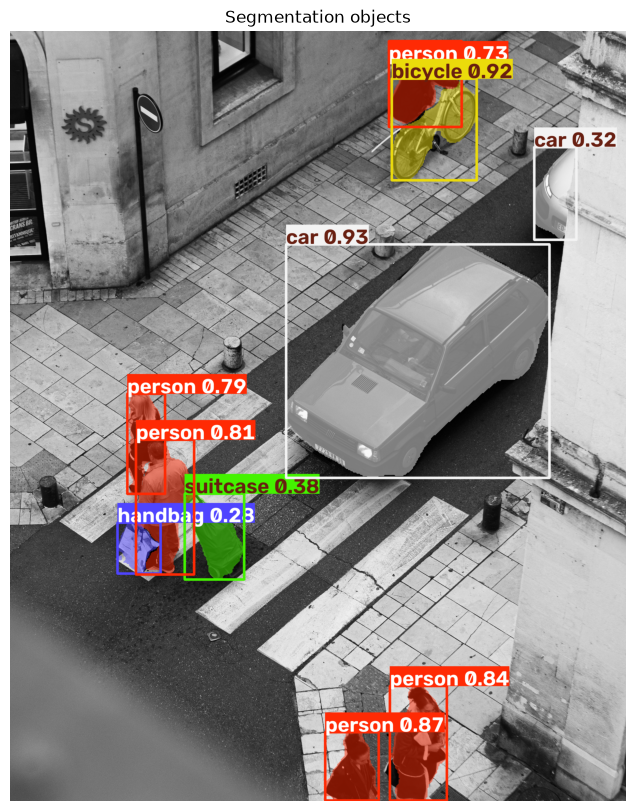

In [160]:
image.show_image()

In [161]:
cen = image.xywhn
cen

array([[    0.66195,     0.42875,      0.4276,     0.30338],
       [    0.68874,     0.12786,     0.13772,     0.13183],
       [    0.55517,     0.95499,    0.086978,    0.088985],
       [    0.66293,     0.92504,    0.092473,     0.14873],
       [    0.25168,     0.61834,    0.094302,     0.17501],
       [    0.22117,     0.53608,    0.061355,     0.13008],
       [    0.67409,    0.068787,     0.11811,      0.1115],
       [    0.33195,      0.6567,    0.096563,     0.11158],
       [    0.88529,     0.21098,    0.068348,     0.12008],
       [    0.20952,     0.67165,    0.069905,    0.065838]], dtype=float32)

In [162]:
cn = image.xyxyn
cn

array([[    0.44815,     0.27706,     0.87575,     0.58044],
       [    0.61988,    0.061948,      0.7576,     0.19378],
       [    0.51168,      0.9105,     0.59866,     0.99949],
       [     0.6167,     0.85068,     0.70917,     0.99941],
       [    0.20453,     0.53084,     0.29883,     0.70585],
       [    0.19049,     0.47104,     0.25185,     0.60111],
       [    0.61504,    0.013036,     0.73315,     0.12454],
       [    0.28367,     0.60092,     0.38023,     0.71249],
       [    0.85112,     0.15094,     0.91946,     0.27102],
       [    0.17456,     0.63874,     0.24447,     0.70457]], dtype=float32)